# Productization - the analysis as something another program can call

**Stage 13.** Companion to `src/service.py`, `app.py` and `docs/productization.md`.

Twelve stages produced an analysis a person runs. This one produces a **service**, and
the difference is not cosmetic: a notebook cannot be called, re-runs work that has not
changed, and interleaves the reasoning with the computation so neither can be reused
without the other.

Three things happen here, in this order, because the order is the point:

1. **The pipeline's steps are extracted into `src/service.py`**, and the extracted
   functions are checked against the original cells to machine precision. A refactor that
   quietly changes a number is worse than no refactor, because the change then enters the
   app where nobody is looking for it.
2. **The model is saved to `model/model.pkl`** with everything needed to reproduce the
   *published* number, which is more than the coefficients.
3. **`app.py` serves it over HTTP**, and this notebook calls that app and keeps the
   output as testing evidence.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import socket
import subprocess
import time

import numpy as np
import pandas as pd
import requests

from src import evaluation as ev, features as fe, modeling as md, service as sv
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP, read_df

PROC, RAW = Path('data/processed'), Path('data/raw')
PORT = 5001
BASE = f'http://127.0.0.1:{PORT}'

def port_is_free(port, host='127.0.0.1'):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.settimeout(0.4)
        return s.connect_ex((host, port)) != 0

print('platform  :', sys.platform)
print(f'port {PORT} :', 'free' if port_is_free(PORT) else 'IN USE - stop the old server first')
print('port 5000 :', 'free' if port_is_free(5000) else 'in use (AirPlay Receiver on macOS), which is why this uses 5001')

platform  : darwin
port 5001 : free
port 5000 : in use (AirPlay Receiver on macOS), which is why this uses 5001


## 1. The original cells

The Stage 12 model, written out the long way exactly as `project_pipeline.ipynb` has it.
These stay here rather than being deleted, because they are the reference the refactor is
checked against. The project instructions ask for precisely this.

In [3]:
clean = sorted(PROC.glob('prices_clean_*.parquet'))
src_path = clean[-1] if clean else sorted(RAW.glob('api_yfinance_*.csv'))[-1]
prices = read_df(src_path) if str(src_path).endswith('parquet') else pd.read_csv(src_path)
prices['date'] = pd.to_datetime(prices['date'])

HORIZON = 21
TARGET = f'y_absdrift_fwd_{HORIZON}'
FIVE = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']

# --- the original cells, unchanged ---
matrix_nb = fe.build_feature_matrix(prices, TARGET_WEIGHTS, prices_raw=prices, horizon=HORIZON)
data_nb = (matrix_nb[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET]]
           .dropna().sort_values(['date', 'ticker']).reset_index(drop=True))
train_nb, test_nb, cut_nb = md.chronological_split(data_nb, test_frac=0.2)
fit_nb = md.fit_ols(train_nb[FIVE].to_numpy(), train_nb[TARGET].to_numpy(), FIVE)
resid_nb = test_nb[TARGET].to_numpy() - md.predict_ols(fit_nb['beta'], test_nb[FIVE].to_numpy())

latest_nb = matrix_nb.sort_values('date').groupby('ticker').tail(1).sort_values('ticker')
point_nb = md.predict_ols(fit_nb['beta'], latest_nb[FIVE].to_numpy())
fcst_nb = ev.prediction_interval(point_nb, resid_nb, level=0.95)

print(f'source {src_path.name} | cut {cut_nb.date()} | train {len(train_nb)} | test {len(test_nb)}')
print(f'MAE {ev.mae(resid_nb):.6f} | RMSE {ev.rmse(resid_nb):.6f} | bias {ev.bias(resid_nb):+.6f}')
print(fcst_nb.round(4).to_string(index=False))

source prices_clean_20260830-1023.parquet | cut 2026-06-01 | train 501 | test 126
MAE 0.175928 | RMSE 0.211219 | bias +0.080240
 point     lo     hi
1.6406 1.3319 2.0409
0.6415 0.3328 1.0418
0.9891 0.6804 1.3894


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta


## 2. The same thing through `src/service.py`

One call. The functions were written to match the cells rather than to improve on them,
including the sort order, which matters more than it looks: `chronological_split` cuts on
dates and the residual vector is positional, so a different sort gives different residuals,
which gives different interval percentiles.

In [4]:
bundle = sv.build_bundle(prices)
matrix = sv.build_matrix(prices)
fcst = sv.forecast(bundle, matrix, level=0.95)

print(sv.describe_bundle(bundle))
print()
print(fcst.round(4).to_string(index=False))

5 features, 6 parameters | fitted 2026-08-30T10:23:10 on 2025-09-30 to 2026-07-30 | cut 2026-06-01 | MAE 0.1759pp

ticker  point     lo     hi      as_of
   BND 1.6406 1.3319 2.0409 2026-08-28
   VTI 0.6415 0.3328 1.0418 2026-08-28
  VXUS 0.9891 0.6804 1.3894 2026-08-28


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta


## 3. The equivalence check

This is the cell that licenses everything downstream. If any of these is not exactly zero,
the app would be serving a different analysis from the one Stage 12 documented, and the
refactor has to be fixed rather than explained.

In [5]:
diffs = {
    'coefficients': np.abs(fit_nb['beta'] - bundle['beta']).max(),
    'test residuals': np.abs(resid_nb - bundle['residuals']).max(),
    'point forecast': np.abs(point_nb - fcst['point'].to_numpy()).max(),
    'interval lower': np.abs(fcst_nb['lo'].to_numpy() - fcst['lo'].to_numpy()).max(),
    'interval upper': np.abs(fcst_nb['hi'].to_numpy() - fcst['hi'].to_numpy()).max(),
    'MAE': abs(ev.mae(resid_nb) - bundle['mae']),
    'bias': abs(ev.bias(resid_nb) - bundle['bias']),
}
for name, d in diffs.items():
    print(f"{'PASS' if d == 0 else 'FAIL'}  {name:<18} max |difference| = {d:.3e}")
print()
exact = all(d == 0 for d in diffs.values())
print('the refactor is exactly the notebook' if exact
      else 'THE REFACTOR CHANGED SOMETHING - do not ship it')
assert exact, 'refactor is not equivalent to the original cells'

PASS  coefficients       max |difference| = 0.000e+00
PASS  test residuals     max |difference| = 0.000e+00
PASS  point forecast     max |difference| = 0.000e+00
PASS  interval lower     max |difference| = 0.000e+00
PASS  interval upper     max |difference| = 0.000e+00
PASS  MAE                max |difference| = 0.000e+00
PASS  bias               max |difference| = 0.000e+00

the refactor is exactly the notebook


## 4. Saving the model, and what has to go in it

**A pickle holding only the coefficients would be a broken deliverable here.** Stage 11
established that the monitor publishes a *prediction interval*, and that interval is built
from the percentiles of the test residuals. A saved model without them can produce a point
forecast and cannot produce the number that actually gets published.

So the bundle carries the residuals, the feature names, the split date, the per-fund bias
offsets from Stage 12, and the window it was fitted on.

**`get_bundle` prefers a saved model to refitting**, which is the option the instructions
ask for and a real risk worth naming: a pickle from last month against this month's prices
gives a forecast that looks current and is not. That is why the fitted window is recorded,
printed by `describe_bundle`, and returned by the API's `/health`. The staleness is made
visible rather than prevented, because a monitor that refuses to answer is worse than one
that answers with its date attached.

In [6]:
saved = sv.save_bundle(bundle, ROOT / 'model' / 'model.pkl')
print(f'saved {saved.relative_to(ROOT)} ({saved.stat().st_size} bytes)')
print()
print('what is in it:')
for k, v in bundle.items():
    shape = f'array{np.shape(v)}' if isinstance(v, np.ndarray) else type(v).__name__
    print(f'  {k:<18} {shape}')
print()

# Prove the file, not the object in memory. The app reads the file.
reloaded, source = sv.get_bundle(path=ROOT / 'model' / 'model.pkl')
print(f'loaded back, source = {source!r}')
print('interval from the reloaded bundle matches the in-memory one:',
      bool(np.array_equal(
          sv.forecast(reloaded, matrix)[['point', 'lo', 'hi']].to_numpy(),
          fcst[['point', 'lo', 'hi']].to_numpy())))

fresh, source_fresh = sv.get_bundle(prices, path=ROOT / 'model' / 'model.pkl', refit=True)
print(f'refit=True forces a new fit, source = {source_fresh!r}, '
      f'same coefficients: {np.array_equal(fresh["beta"], bundle["beta"])}')

saved model/model.pkl (3536 bytes)

what is in it:
  version            int
  beta               array(6,)
  features           list
  target             str
  horizon            int
  target_weights     dict
  residuals          array(126,)
  test_dates         array(126,)
  test_tickers       array(126,)
  per_fund_bias      dict
  cut_date           Timestamp
  n_train            int
  n_test             int
  n_test_dates       int
  data_start         Timestamp
  data_end           Timestamp
  mae                float
  rmse               float
  bias               float
  fitted_at          str

loaded back, source = 'loaded'
interval from the reloaded bundle matches the in-memory one: True
refit=True forces a new fit, source = 'fitted', same coefficients: True


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta


## 5. Start the API

`app.py` is launched as a subprocess of this kernel and shut down in the last cell, so a
Restart-and-Run-All leaves nothing bound to the port. The lecture's
`os.system("start cmd /k python app.py")` is a Windows command and does nothing on macOS.

The server is polled on `/health` rather than slept on: a fixed sleep is either wasteful or,
on a busy machine, too short, and then the next cell fails for a reason that has nothing to
do with the code.

In [7]:
if not port_is_free(PORT):
    raise RuntimeError(f'something is already listening on {PORT}. '
                       'Run the last cell of this notebook, or stop it, then re-run.')

env = dict(os.environ, PORT=str(PORT))
log = open('server.log', 'w')
server = subprocess.Popen([sys.executable, 'app.py'], stdout=log,
                          stderr=subprocess.STDOUT, env=env, cwd=str(ROOT))

deadline, ready = time.time() + 60, False
while time.time() < deadline:
    if server.poll() is not None:
        break
    try:
        if requests.get(BASE + '/health', timeout=1).status_code == 200:
            ready = True
            break
    except requests.exceptions.RequestException:
        time.sleep(0.4)

log.flush()
if not ready:
    print('SERVER DID NOT START. server.log:')
    print(Path('server.log').read_text()[-2500:])
    raise RuntimeError('server failed to start')

health = requests.get(BASE + '/health', timeout=10).json()
print(f'server up on {BASE}, pid {server.pid}')
print()
for k in ['status', 'model_source', 'model', 'prices_through', 'price_source']:
    print(f'  {k:<15} {health[k]}')
print(f"  {'fitted_on':<15} {health['fitted_on']}")

server up on http://127.0.0.1:5001, pid 78940

  status          ok
  model_source    loaded
  model           5 features, 6 parameters | fitted 2026-08-30T10:23:10 on 2025-09-30 to 2026-07-30 | cut 2026-06-01 | MAE 0.1759pp
  prices_through  2026-08-28
  price_source    prices_clean_20260830-1023.parquet
  fitted_on       {'cut': '2026-06-01', 'end': '2026-07-30', 'start': '2025-09-30'}


## 6. Call the API

The testing evidence the instructions ask for. Every route, plus the failure cases.

In [8]:
def show(label, response, limit=210):
    ct = response.headers.get('Content-Type', '').split(';')[0]
    body = response.text[:limit] if ct in ('application/json', 'text/csv') \
        else f'<{len(response.content)} bytes>'
    print(f'{label:<34} {response.status_code}  {ct:<18}')
    print(f'{"":<34} {body}')
    print()
    return response

r_predict = show('POST /predict',
                 requests.post(BASE + '/predict',
                               json={'features': [1.70, 17.05, 0.01, 0.05, 0.5]}, timeout=10))
r_fund = show('GET  /predict/BND', requests.get(BASE + '/predict/BND', timeout=10))
r_full = show('GET  /run_full_analysis', requests.get(BASE + '/run_full_analysis', timeout=60))
r_csv = show('GET  /monitor.csv', requests.get(BASE + '/monitor.csv', timeout=30))

POST /predict                      200  application/json  
                                   {"band":"green","features":{"abs_drift":1.7,"abs_drift_rel":17.05,"drift_chg_1":0.01,"drift_chg_5":0.05,"drift_slope_21":0.5},"horizon_trading_days":21,"interval_95_pp":[1.3245669127121844,2.033573377937957],"p

GET  /predict/BND                  200  application/json  
                                   {"action":"no action","as_of":"2026-08-28","band":"green","drift_today_pp":1.7049,"fund":"BND","interval_95_pp":[1.3319,2.0409],"projected_adjusted_pp":1.4902,"projected_pp":1.6406,"worst_case_band":"green"}


GET  /run_full_analysis            200  application/json  
                                   {"any_action_needed":false,"as_of":"2026-08-28","headline":"No fund needs attention: the widest 95% upper bound is 2.04pp against an amber line of 3.0pp.","level":0.95,"model":"5 features, 6 parameters | fitted

GET  /monitor.csv                  200  text/csv          
                         

### The parameterised route

`/run_full_analysis/<amber>/<red>` is the "user-provided inputs modify part of the
analysis" route from the instructions, and the input it exposes is the **threshold**.

That is a deliberate choice rather than a convenient one. Stage 07 set amber at 3pp and red
at 5pp and left the question with the principal. Stage 12 closed the question of the *unit*
(pp against relative, 25.8% improvement against 25.6%) but said nothing about the *level*.
So "what would this look like at 2pp" is a live question, and it is now answerable without
anyone opening a notebook.

In [9]:
default = requests.get(BASE + '/run_full_analysis', timeout=60).json()
tighter = requests.get(BASE + '/run_full_analysis/2/4', timeout=60).json()

print('amber 3.0pp (as published)')
print('  ', default['headline'])
print('   action needed:', default['any_action_needed'])
print()
print('amber 2.0pp (what the principal might ask for)')
print('  ', tighter['headline'])
print('   action needed:', tighter['any_action_needed'])
print()
print('The verdict flips. BND projects to 1.64pp with an upper bound of 2.04pp, so it')
print('clears a 3pp line comfortably and fails a 2pp one on the interval, not the point.')
print()
print(pd.DataFrame(tighter['monitor'])[['fund', 'projected_21d_pp', 'upper_95_pp',
                                        'worst_case_band', 'action']].to_string(index=False))

amber 3.0pp (as published)
   No fund needs attention: the widest 95% upper bound is 2.04pp against an amber line of 3.0pp.
   action needed: False

amber 2.0pp (what the principal might ask for)
   Review needed: BND can reach 2.04pp against an amber line of 2.0pp.
   action needed: True

The verdict flips. BND projects to 1.64pp with an upper bound of 2.04pp, so it
clears a 3pp line comfortably and fails a 2pp one on the interval, not the point.

fund  projected_21d_pp  upper_95_pp worst_case_band                action
 VTI            0.6415       1.0418           green             no action
VXUS            0.9891       1.3894           green             no action
 BND            1.6406       2.0409           amber review with principal


In [10]:
bad_cases = [
    ('unknown fund',            lambda: requests.get(BASE + '/predict/AAPL', timeout=10)),
    ('POST, no features key',   lambda: requests.post(BASE + '/predict', json={}, timeout=10)),
    ('POST, too few features',  lambda: requests.post(BASE + '/predict', json={'features': [1.0]}, timeout=10)),
    ('POST, a string feature',  lambda: requests.post(BASE + '/predict', json={'features': ['x', 1, 2, 3, 4]}, timeout=10)),
    ('threshold not a number',  lambda: requests.get(BASE + '/run_full_analysis/abc/4', timeout=10)),
    ('red below amber',         lambda: requests.get(BASE + '/run_full_analysis/5/2', timeout=10)),
    ('unknown route',           lambda: requests.get(BASE + '/predictt/BND', timeout=10)),
]
for label, call in bad_cases:
    r = call()
    ok = r.status_code in (400, 404) and 'application/json' in r.headers.get('Content-Type', '')
    print(f"{'PASS' if ok else 'FAIL'}  {label:<24} {r.status_code}  {r.json().get('error')}")

PASS  unknown fund             400  unknown fund 'AAPL'
PASS  POST, no features key    400  missing 'features': send a list of 5 numbers
PASS  POST, too few features   400  expected exactly 5 features, got 1
PASS  POST, a string feature   400  feature 0 (abs_drift) must be a number, got 'x'
PASS  threshold not a number   400  amber must be a number, got 'abc'
PASS  red below amber          400  red (2.0) must be greater than amber (5.0)
PASS  unknown route            404  no such route


GET /plot      -> 200 image/png 116400 bytes
GET /plot?amber=2.0 -> 200 image/png 127136 bytes
.json() on it raises JSONDecodeError, as it should - it is a PNG
saved reports/images/api_plot_route.png


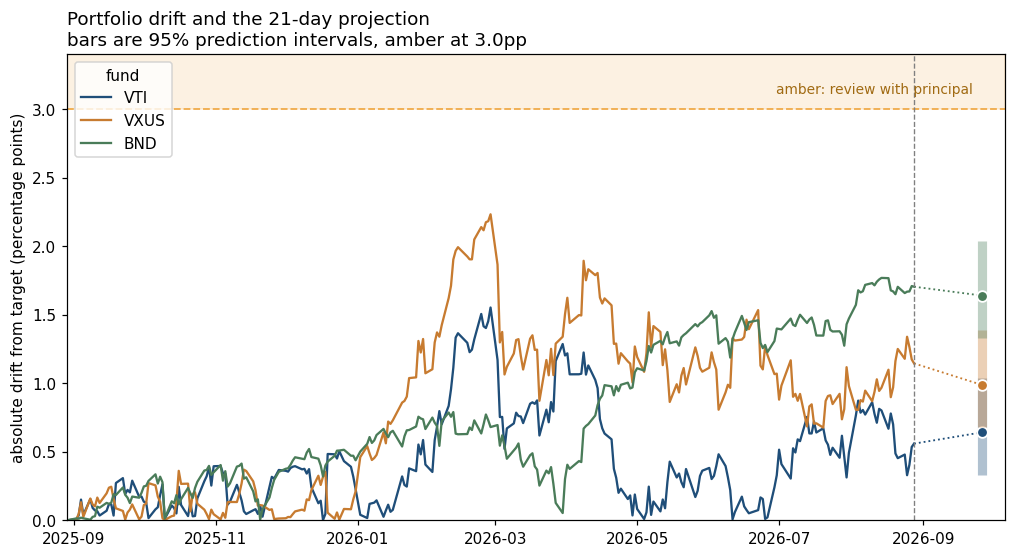

In [11]:
plot = requests.get(BASE + '/plot', timeout=60)
print('GET /plot      ->', plot.status_code, plot.headers.get('Content-Type'),
      f'{len(plot.content)} bytes')

plot2 = requests.get(BASE + '/plot', params={'amber': 2.0}, timeout=60)
print('GET /plot?amber=2.0 ->', plot2.status_code, plot2.headers.get('Content-Type'),
      f'{len(plot2.content)} bytes')

try:
    plot.json()
except Exception as e:
    print(f'.json() on it raises {type(e).__name__}, as it should - it is a PNG')

Path('reports/images').mkdir(parents=True, exist_ok=True)
Path('reports/images/api_plot_route.png').write_bytes(plot.content)
print('saved reports/images/api_plot_route.png')

from IPython.display import Image, display
display(Image(plot.content))

## 7. The API and the notebook agree

The point of the equivalence check in section 3 was that the refactor did not change the
analysis. This is the same check one layer out: the number coming back over HTTP is the
number the notebook computes.

In [12]:
api_rows = {r['fund']: r for r in default['monitor']}
notebook_table = sv.monitor(bundle, matrix)

agree = {}
for _, row in notebook_table.iterrows():
    fund = row['fund']
    agree[f'{fund} projected'] = abs(api_rows[fund]['projected_21d_pp'] - row['projected_21d_pp']) < 1e-9
    agree[f'{fund} upper 95'] = abs(api_rows[fund]['upper_95_pp'] - row['upper_95_pp']) < 1e-9
    agree[f'{fund} band'] = api_rows[fund]['worst_case_band'] == row['worst_case_band']

csv_from_api = pd.read_csv(pd.io.common.StringIO(r_csv.text))
agree['monitor.csv matches the notebook table'] = bool(
    np.allclose(csv_from_api['projected_21d_pp'].to_numpy(),
                notebook_table['projected_21d_pp'].to_numpy()))

for k, v in agree.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")
print()
print('the API serves the analysis this project documented' if all(agree.values())
      else 'THE API AND THE NOTEBOOK DISAGREE')

PASS  VTI projected
PASS  VTI upper 95
PASS  VTI band
PASS  VXUS projected
PASS  VXUS upper 95
PASS  VXUS band
PASS  BND projected
PASS  BND upper 95
PASS  BND band
PASS  monitor.csv matches the notebook table

the API serves the analysis this project documented


## 8. Check, then stop the server

In [13]:
checks = {
    'refactor is exactly the original cells': exact,
    'model/model.pkl exists': (ROOT / 'model' / 'model.pkl').exists(),
    'the bundle carries residuals, not just coefficients':
        'residuals' in bundle and len(bundle['residuals']) == bundle['n_test'],
    'a reloaded bundle reproduces the interval': bool(np.array_equal(
        sv.forecast(reloaded, matrix)[['point', 'lo', 'hi']].to_numpy(),
        fcst[['point', 'lo', 'hi']].to_numpy())),
    'app.py loads its model at import time, not per request':
        'BUNDLE, MODEL_SOURCE = sv.get_bundle' in
        Path('app.py').read_text().split('@app.route')[0],
    'POST /predict returned 200': r_predict.status_code == 200,
    'GET /predict/<ticker> returned 200': r_fund.status_code == 200,
    'GET /run_full_analysis returned 200': r_full.status_code == 200,
    'GET /monitor.csv returned text/csv':
        r_csv.headers.get('Content-Type', '').startswith('text/csv'),
    'GET /plot returned image/png': plot.headers.get('Content-Type') == 'image/png',
    'the threshold route changes the verdict':
        default['any_action_needed'] is False and tighter['any_action_needed'] is True,
    'the API agrees with the notebook': all(agree.values()),
    'requirements.txt exists': Path('requirements.txt').exists(),
    'README.md documents the API': 'run_full_analysis' in Path('README.md').read_text(),
}
for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")
print()
print('all checks passed' if all(checks.values()) else 'SOMETHING FAILED - fix before committing')

PASS  refactor is exactly the original cells
PASS  model/model.pkl exists
PASS  the bundle carries residuals, not just coefficients
PASS  a reloaded bundle reproduces the interval
PASS  app.py loads its model at import time, not per request
PASS  POST /predict returned 200
PASS  GET /predict/<ticker> returned 200
PASS  GET /run_full_analysis returned 200
PASS  GET /monitor.csv returned text/csv
PASS  GET /plot returned image/png
PASS  the threshold route changes the verdict
PASS  the API agrees with the notebook
PASS  requirements.txt exists
PASS  README.md documents the API

all checks passed


In [14]:
server.terminate()
try:
    server.wait(timeout=15)
except subprocess.TimeoutExpired:
    server.kill()
    server.wait(timeout=15)
log.close()

print(f'server stopped, exit code {server.returncode}')
print(f'port {PORT} free again:', port_is_free(PORT))

server stopped, exit code -15
port 5001 free again: True


## What Stage 13 changed

**The analysis became callable.** `src/service.py` holds the chain as functions, `app.py`
serves them, and both were checked against the original notebook cells to exactly zero
difference rather than to a tolerance.

**The saved model carries what the published number needs.** Coefficients alone would give
a point forecast and not the prediction interval Stage 11 and 12 argued the monitor must
publish, so the bundle carries the test residuals, the per-fund bias offsets and the window
it was fitted on.

**Dana can reach the model without a Python environment.** `GET /monitor.csv` returns her
Stage 12 table over HTTP as a download. That is the shortest path from this model to her
spreadsheet, and it is why the route exists alongside the JSON one.

**The principal can ask a question the project left open.** `/run_full_analysis/2/4` moves
the threshold Stage 07 set and Stage 12 declined to settle. At 2pp the verdict flips, and
it flips on BND's interval rather than its point estimate, which is the distinction Stage
11 spent its length establishing.

**Nothing about the data, the model or the thresholds changed.** Stage 13 packages; the
defaults are still 3pp and 5pp.